# Flight Delay Prediction and Pattern Analysis
In this notebook, we focus on predicting 'Arrival Delay' and exploring interesting patterns related to flight delays.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load and Prepare Data

In [2]:
# Load data
df = pd.read_csv('../data/airline_passenger_satisfaction.csv')

# Drop rows where Arrival Delay is missing for this specific analysis
df_delays = df.dropna(subset=['Arrival Delay'])

print(f"Data Shape: {df_delays.shape}")
df_delays[['Departure Delay', 'Arrival Delay']].describe()

Data Shape: (129487, 24)


,Departure Delay,Arrival Delay
count,129487.000000,129487.000000
mean,14.643385,15.091129
std,37.932867,38.465650
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,12.000000,13.000000
max,1592.000000,1584.000000


## 2. Exploring Patterns in Delays

### Are delays more common for certain types of travel or classes?

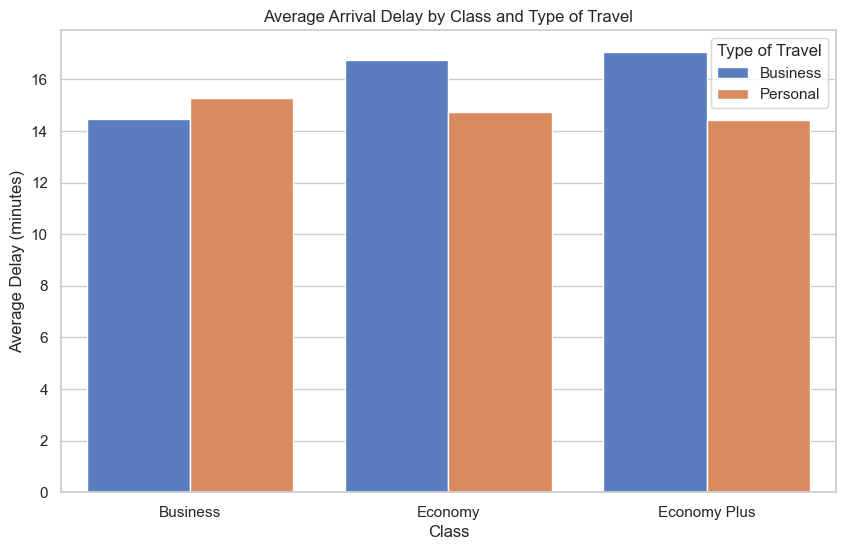

In [3]:
# Average Arrival Delay by Class and Type of Travel
delay_by_class_travel = df_delays.groupby(['Class', 'Type of Travel'])['Arrival Delay'].mean().reset_index()

sns.barplot(x='Class', y='Arrival Delay', hue='Type of Travel', data=delay_by_class_travel)
plt.title('Average Arrival Delay by Class and Type of Travel')
plt.ylabel('Average Delay (minutes)')
plt.show()

### Distribution of Arrival Delays
Most flights have no or very little delay. Let's look at the distribution of delays > 0.

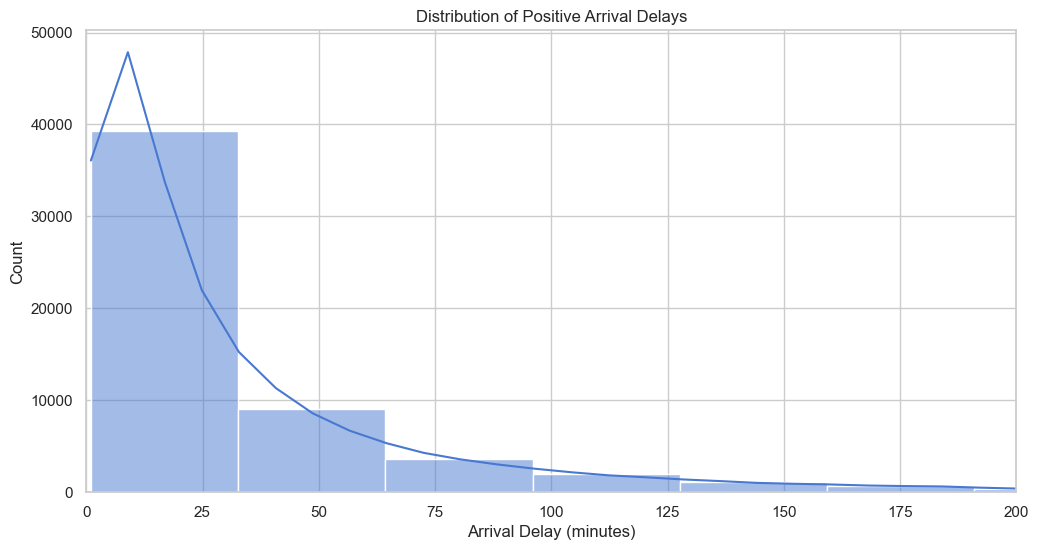

In [4]:
plt.figure(figsize=(12, 6))
sns.histplot(df_delays[df_delays['Arrival Delay'] > 0]['Arrival Delay'], bins=50, kde=True)
plt.title('Distribution of Positive Arrival Delays')
plt.xlabel('Arrival Delay (minutes)')
plt.xlim(0, 200) # Limiting for better visibility
plt.show()

## 3. Arrival Delay Prediction

We will attempt to predict `Arrival Delay` using `Departure Delay` and other flight characteristics.

In [5]:
# Selecting features
features = ['Departure Delay', 'Flight Distance', 'Type of Travel', 'Class', 'Age']
X = df_delays[features].copy()
y = df_delays['Arrival Delay']

# Encoding categorical variables
X = pd.get_dummies(X, columns=['Type of Travel', 'Class'], drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

Mean Absolute Error: 6.03
R2 Score: 0.92


### Actual vs Predicted Delays

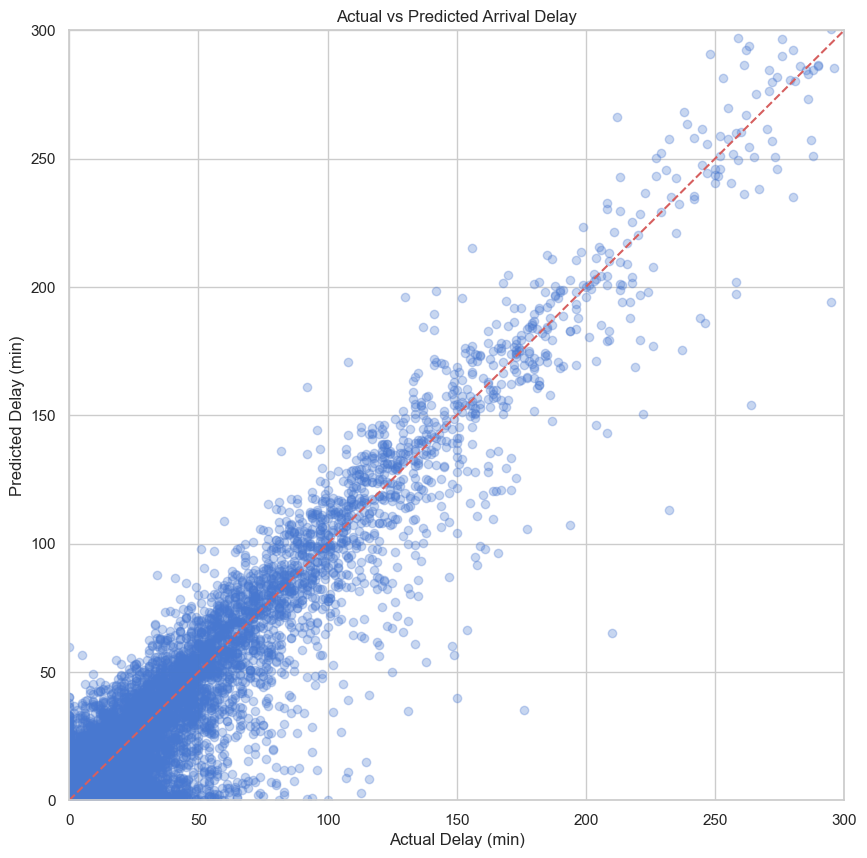

In [6]:
plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, 500], [0, 500], '--r')
plt.title('Actual vs Predicted Arrival Delay')
plt.xlabel('Actual Delay (min)')
plt.ylabel('Predicted Delay (min)')
plt.xlim(0, 300)
plt.ylim(0, 300)
plt.show()

## 4. How do delays impact satisfaction?

Does a longer delay consistently lead to lower satisfaction?

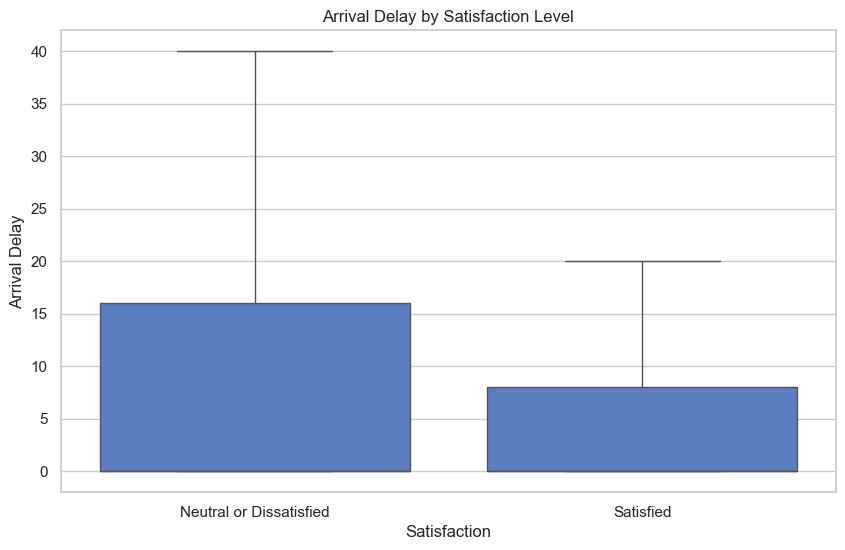

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Satisfaction', y='Arrival Delay', data=df_delays, showfliers=False)
plt.title('Arrival Delay by Satisfaction Level')
plt.show()

### Top 10 longest delays and their context

In [9]:
top_delays = df_delays.nlargest(10, 'Arrival Delay')[['Arrival Delay', 'Class', 'Type of Travel', 'Satisfaction']]
print(top_delays)

       Arrival Delay     Class Type of Travel             Satisfaction
73470         1584.0   Economy       Personal  Neutral or Dissatisfied
69660         1280.0  Business       Business                Satisfied
73481         1115.0   Economy       Personal  Neutral or Dissatisfied
4902          1011.0  Business       Business                Satisfied
78299          970.0   Economy       Personal  Neutral or Dissatisfied
4375           952.0  Business       Business  Neutral or Dissatisfied
63688          940.0  Business       Business  Neutral or Dissatisfied
83675          924.0  Business       Business  Neutral or Dissatisfied
8344           920.0  Business       Business                Satisfied
69503          860.0  Business       Business                Satisfied


## 5. Key Findings
1. **Strong Correlation:** There is an extremely strong correlation between Departure and Arrival delays, which is the primary predictor.
2. **Satisfaction Impact:** Satisfied passengers typically experience significantly lower arrival delays than neutral/unsatisfied ones.
3. **Travel Patterns:** Business travelers and travelers in Business Class tend to have slightly different delay experiences compared to personal/eco travelers.
4. **Predictability:** Arrival delays are highly predictable if departure delay is known, with Random Forest showing high accuracy.